In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter, HourLocator, MinuteLocator
import matplotlib.dates as mdates
import datetime as dt
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 所有库导入完成")

✓ 所有库导入完成


## 第一步：数据加载与时间处理

In [64]:
# 读取数据
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ 成功读取数据，形状：{df.shape}")
except Exception as e:
    raise RuntimeError(f"读取失败：{e}")

# 提取列信息
time_col = df.columns[0]  # 第一列为时间
target_col = df.columns[-1]  # 最后一列为 CO2

print(f"\n数据基本信息：")
print(f"  • 样本数：{len(df)}")
print(f"  • 时间列：{time_col}")
print(f"  • 目标列：{target_col}")
print(f"  • 数据跨度：约 {len(df)/60:.1f} 小时（{len(df)} 分钟）")

# 选定的 10 个特征
selected_features = ['TI-34', 'TI-33', 'TI-24', 'FI-38', 'TI-32', 
                     'TI-242', 'TI-25', 'TI-30', 'FI-36', 'FI-30']

# 验证特征是否存在
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f"\n⚠ 警告：以下特征不存在：{missing_features}")
    print(f"实际列名：{list(df.columns)}")
    selected_features = [f for f in selected_features if f in df.columns]

print(f"\n使用的特征（共 {len(selected_features)} 个）：")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

✓ 成功读取数据，形状：(10080, 59)

数据基本信息：
  • 样本数：10080
  • 时间列：Date
  • 目标列：CO2 capacity
  • 数据跨度：约 168.0 小时（10080 分钟）

使用的特征（共 10 个）：
  1. TI-34
  2. TI-33
  3. TI-24
  4. FI-38
  5. TI-32
  6. TI-242
  7. TI-25
  8. TI-30
  9. FI-36
  10. FI-30


## 第二步：TI-34 特征散点图

数据信息：
  • 样本数：10080
  • 时间范围：2020-01-20 00:00:00 到 2020-02-01 23:59:00
  • 时间跨度：12 天
✓ TI-34 散点图已保存为 TI-34_scatter.png
✓ TI-34 散点图已保存为 TI-34_scatter.png


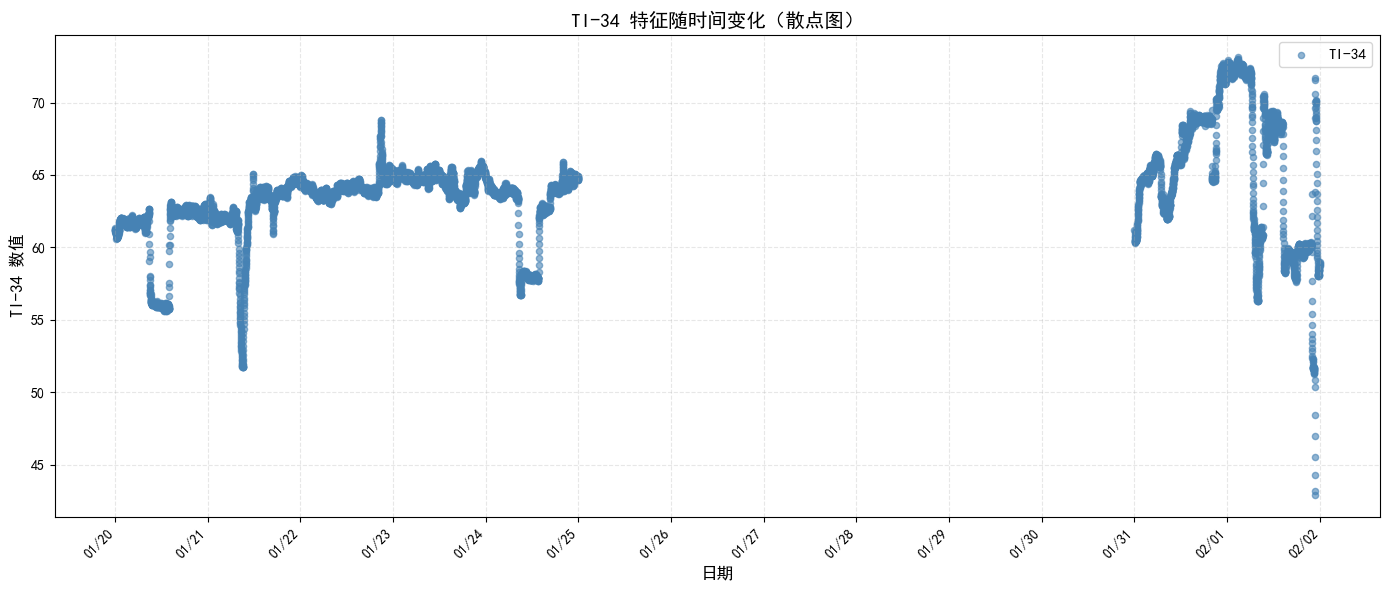

In [65]:
# 提取 TI-34 数据
ti34_data = df['TI-34'].values

# ---------------------------
#   使用实际时间数据
# ---------------------------
# 确保时间列是 datetime 类型
if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
    df[time_col] = pd.to_datetime(df[time_col])

time_index = df[time_col]

print(f"数据信息：")
print(f"  • 样本数：{len(df)}")
print(f"  • 时间范围：{time_index.min()} 到 {time_index.max()}")
print(f"  • 时间跨度：{(time_index.max() - time_index.min()).days} 天")

# ---------------------------
#   绘制散点图（使用实际时间）
# ---------------------------
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(time_index, ti34_data, alpha=0.6, s=20, color='steelblue', label='TI-34')

# ---------------------------
#   设置 x 轴日期刻度（每天一个）
# ---------------------------
ax.xaxis.set_major_locator(mdates.DayLocator())               # 每天一个刻度
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))   # 月/日格式

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')       # 旋转刻度标签

# 禁用小刻度
ax.minorticks_off()

# ---------------------------
#   标签和标题
# ---------------------------
ax.set_xlabel('日期', fontsize=12, fontweight='bold')
ax.set_ylabel('TI-34 数值', fontsize=12, fontweight='bold')
ax.set_title('TI-34 特征随时间变化（散点图）', fontsize=14, fontweight='bold')

ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('TI-34_scatter.png', dpi=300, bbox_inches='tight')
print("✓ TI-34 散点图已保存为 TI-34_scatter.png")
plt.show()


## 第三步：其他 9 个特征的散点图

✓ TI-33 散点图已保存为 TI-33_scatter.png


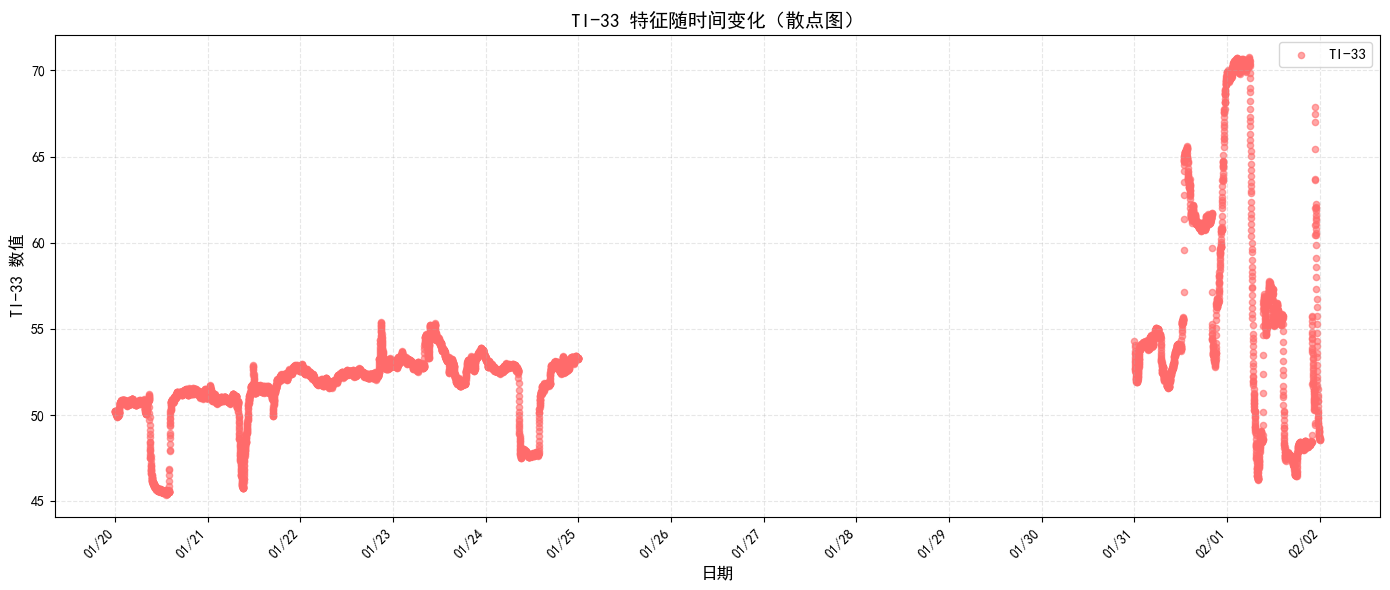


TI-33 统计信息：
  • 最小值：45.3764
  • 最大值：70.8097
  • 平均值：53.0834
  • 标准差：4.7209
  • 样本数：10080

✓ TI-24 散点图已保存为 TI-24_scatter.png
✓ TI-24 散点图已保存为 TI-24_scatter.png


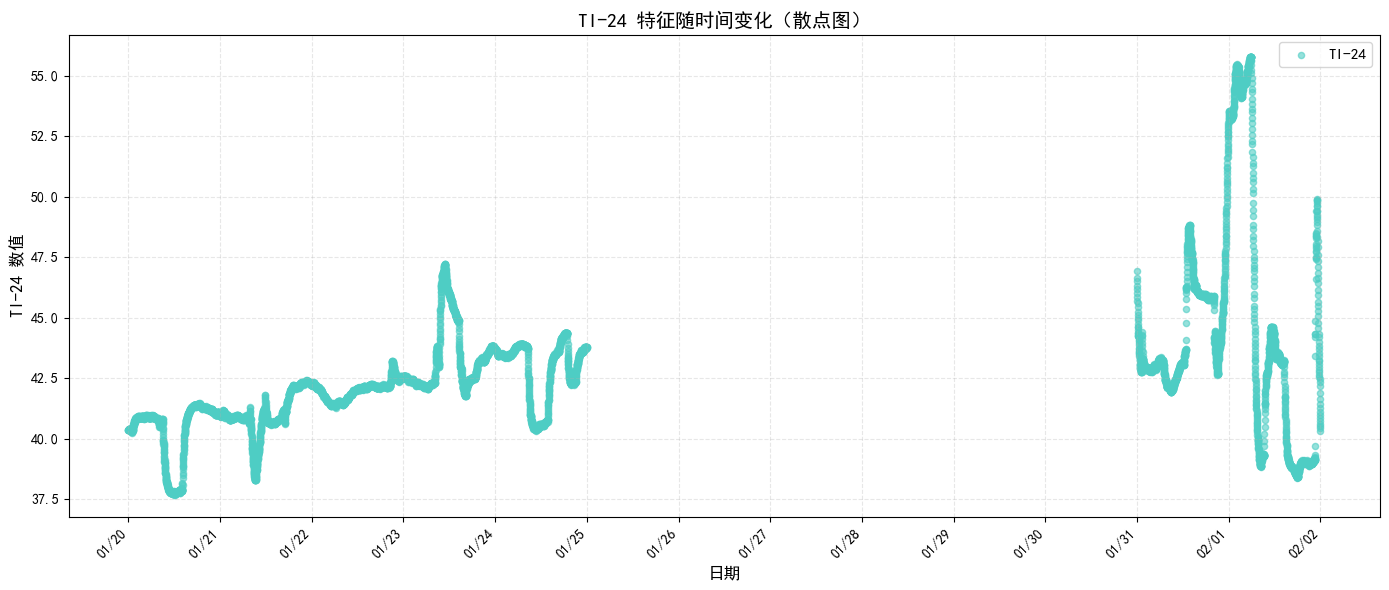


TI-24 统计信息：
  • 最小值：37.6834
  • 最大值：55.7903
  • 平均值：42.6851
  • 标准差：3.1012
  • 样本数：10080

✓ FI-38 散点图已保存为 FI-38_scatter.png
✓ FI-38 散点图已保存为 FI-38_scatter.png


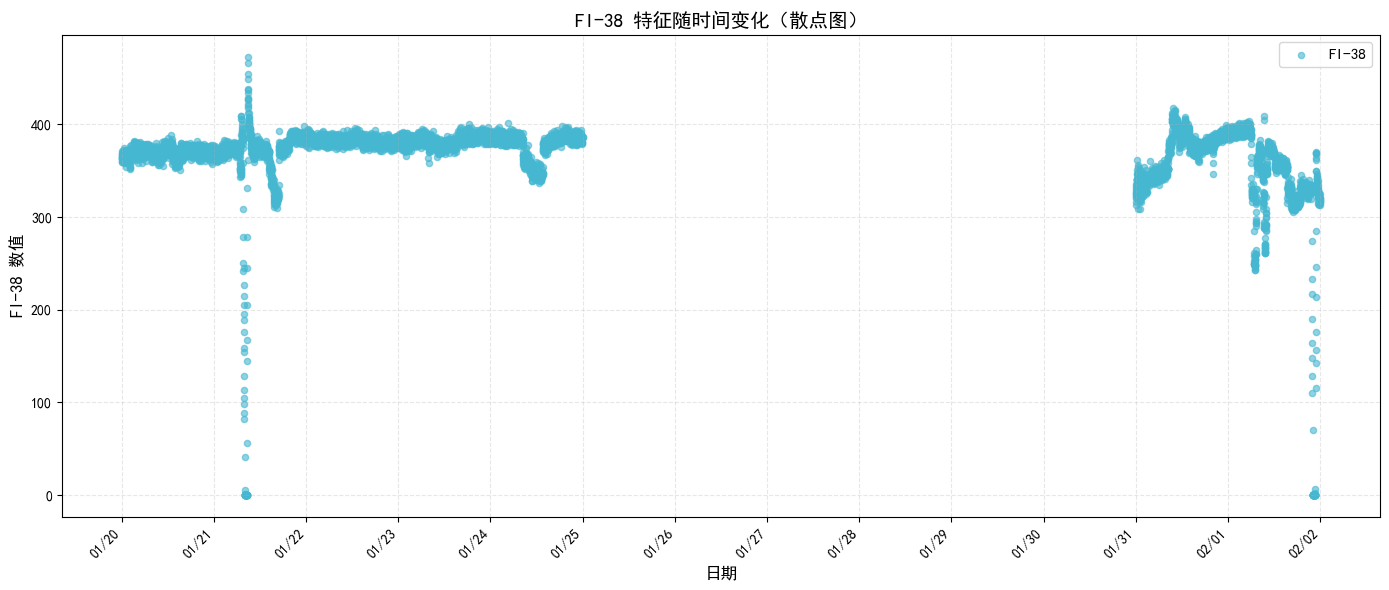


FI-38 统计信息：
  • 最小值：0.0700
  • 最大值：473.1332
  • 平均值：368.3340
  • 标准差：41.5100
  • 样本数：10080

✓ TI-32 散点图已保存为 TI-32_scatter.png
✓ TI-32 散点图已保存为 TI-32_scatter.png


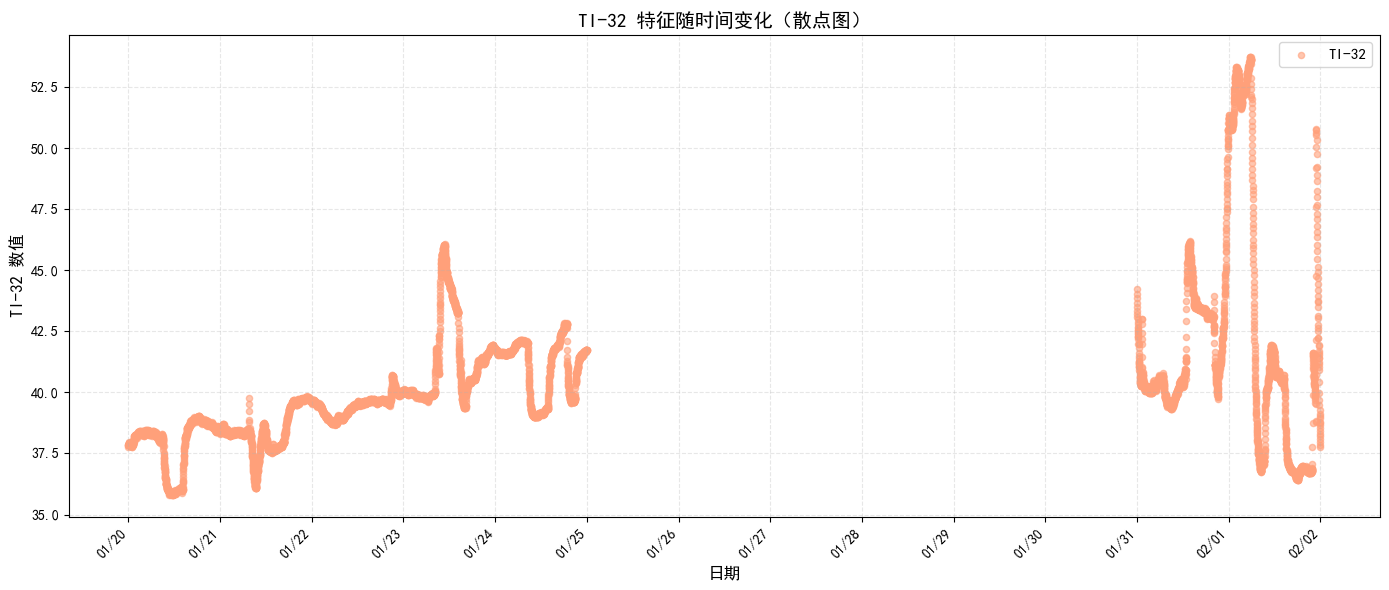


TI-32 统计信息：
  • 最小值：35.8040
  • 最大值：53.7432
  • 平均值：40.3535
  • 标准差：3.1330
  • 样本数：10080

✓ TI-242 散点图已保存为 TI-242_scatter.png
✓ TI-242 散点图已保存为 TI-242_scatter.png


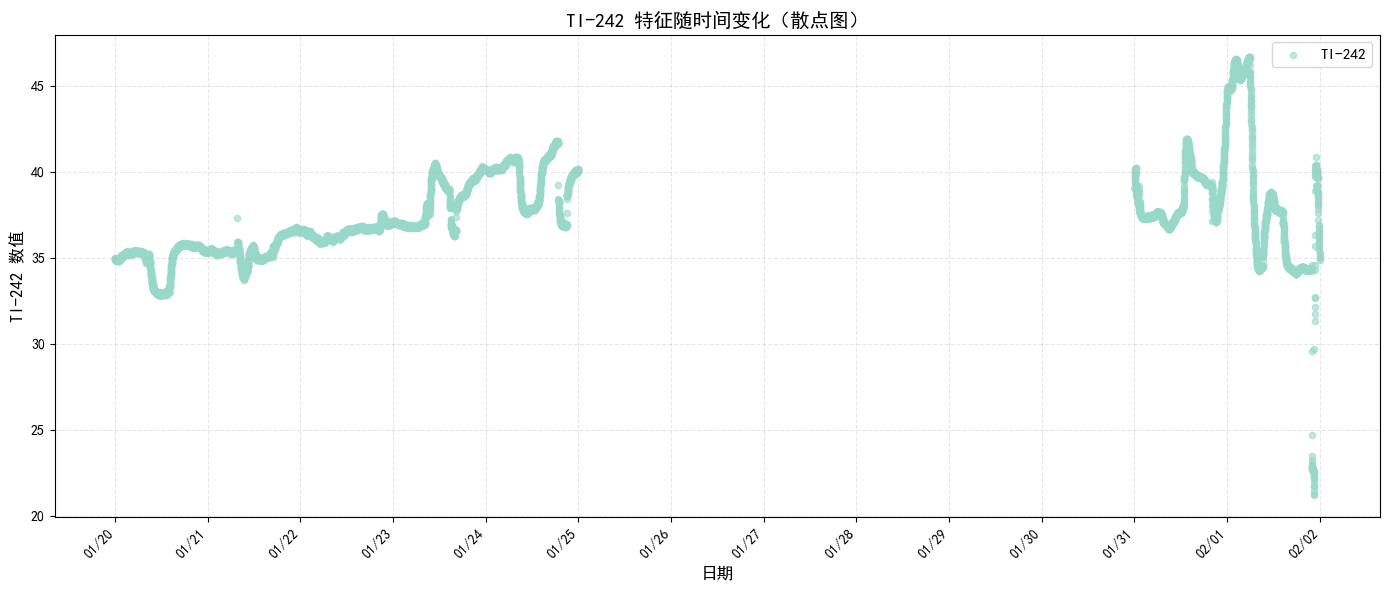


TI-242 统计信息：
  • 最小值：21.1999
  • 最大值：46.6854
  • 平均值：37.3359
  • 标准差：2.7660
  • 样本数：10080

✓ TI-25 散点图已保存为 TI-25_scatter.png
✓ TI-25 散点图已保存为 TI-25_scatter.png


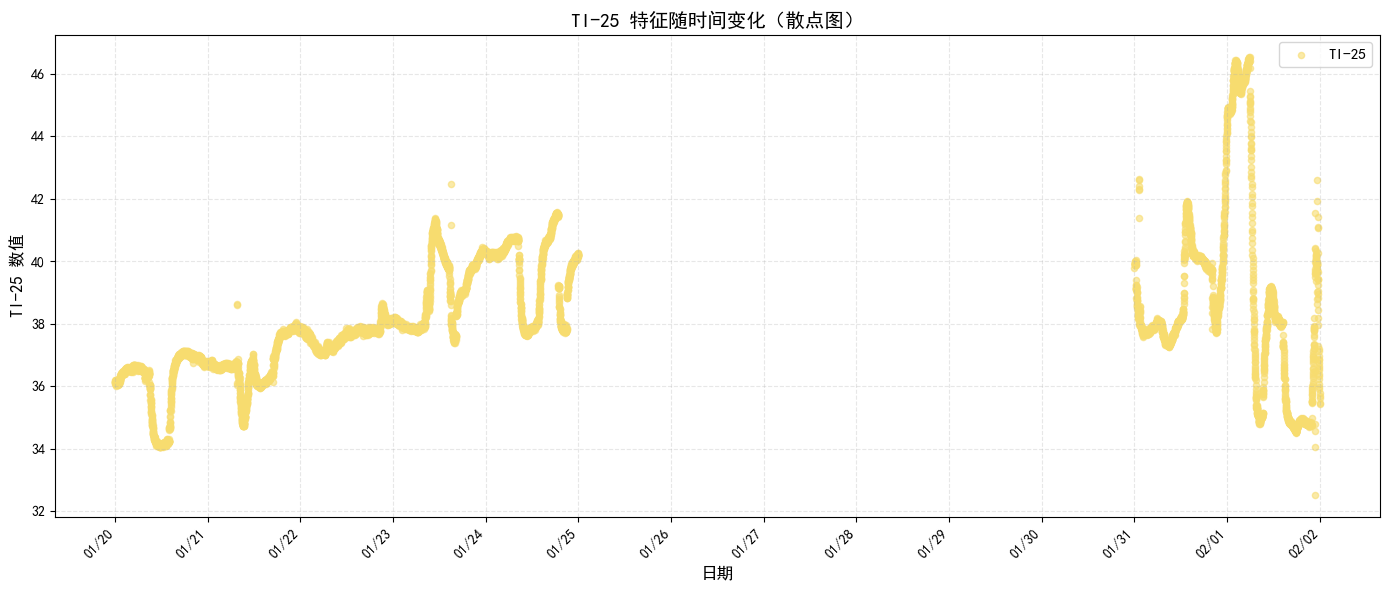


TI-25 统计信息：
  • 最小值：32.5247
  • 最大值：46.5591
  • 平均值：38.1514
  • 标准差：2.2602
  • 样本数：10080

✓ TI-30 散点图已保存为 TI-30_scatter.png
✓ TI-30 散点图已保存为 TI-30_scatter.png


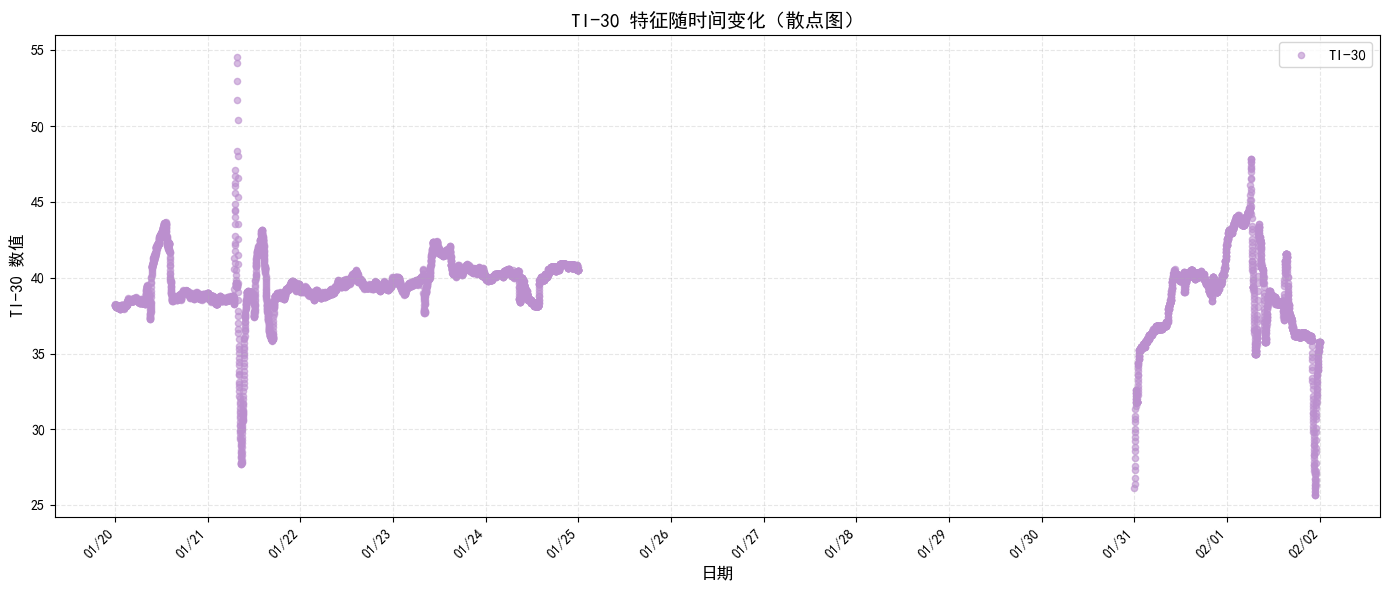


TI-30 统计信息：
  • 最小值：25.6865
  • 最大值：54.5992
  • 平均值：39.3137
  • 标准差：2.2180
  • 样本数：10080

✓ FI-36 散点图已保存为 FI-36_scatter.png
✓ FI-36 散点图已保存为 FI-36_scatter.png


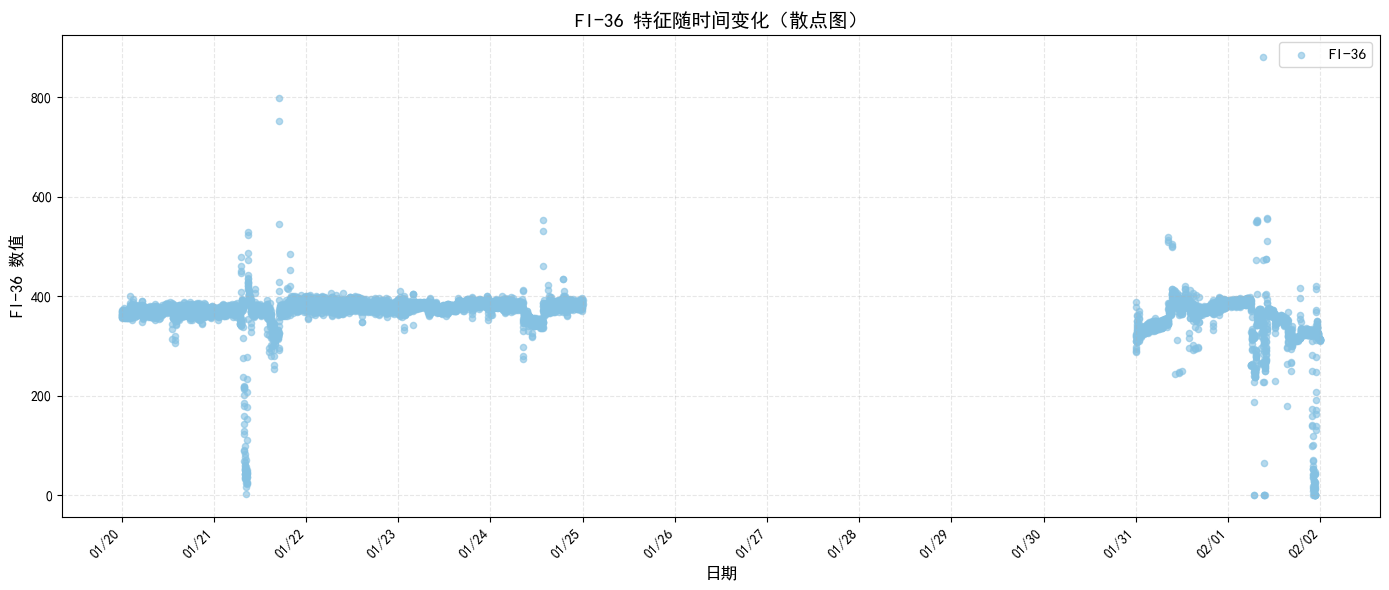


FI-36 统计信息：
  • 最小值：0.4859
  • 最大值：882.2947
  • 平均值：366.6198
  • 标准差：42.4547
  • 样本数：10080

✓ FI-30 散点图已保存为 FI-30_scatter.png
✓ FI-30 散点图已保存为 FI-30_scatter.png


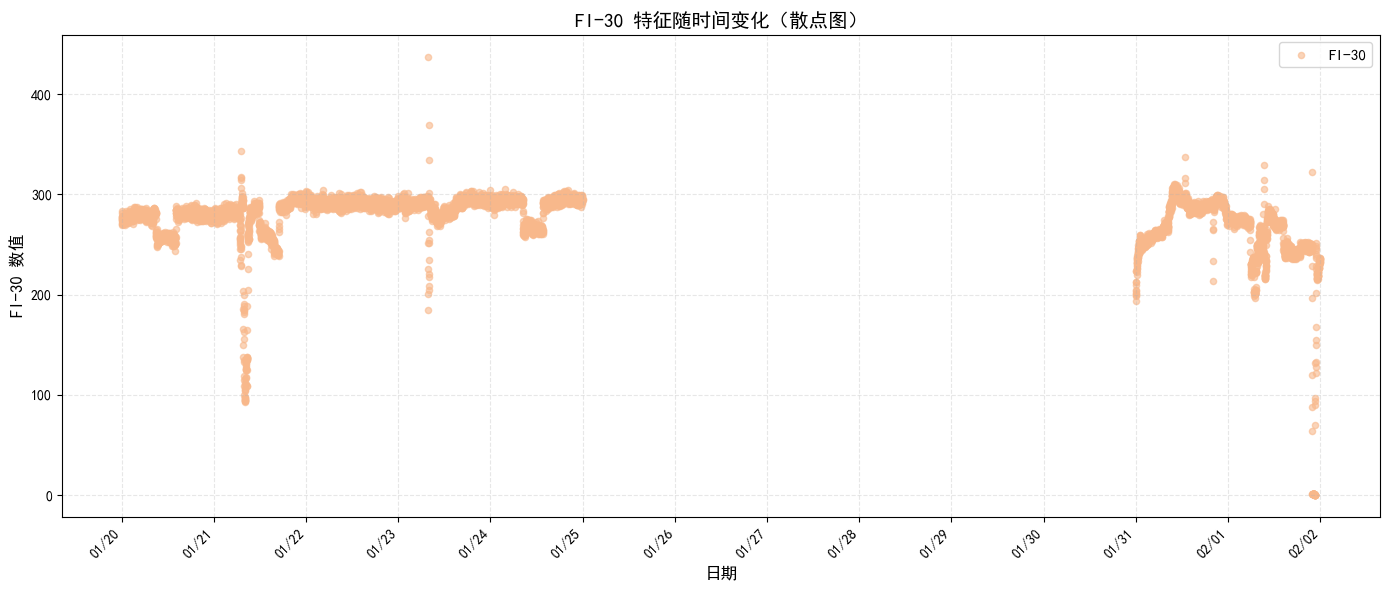


FI-30 统计信息：
  • 最小值：0.0729
  • 最大值：437.4948
  • 平均值：276.9814
  • 标准差：28.8188
  • 样本数：10080



In [66]:
# 为其他 9 个特征绘制散点图
other_features = ['TI-33', 'TI-24', 'FI-38', 'TI-32', 'TI-242', 'TI-25', 'TI-30', 'FI-36', 'FI-30']
colors_map = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B']

for feature, color in zip(other_features, colors_map):
    if feature not in df.columns:
        print(f"⚠ 特征 {feature} 不存在，跳过")
        continue
    
    feature_data = df[feature].values
    
    # 绘制散点图
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.scatter(time_index, feature_data, alpha=0.6, s=20, color=color, label=feature)
    
    # 设置 x 轴日期刻度
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    # 禁用小刻度
    ax.minorticks_off()
    
    # 标签和标题
    ax.set_xlabel('日期', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{feature} 数值', fontsize=12, fontweight='bold')
    ax.set_title(f'{feature} 特征随时间变化（散点图）', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11)
    
    # 保存和显示
    filename = f'{feature}_scatter.png'
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ {feature} 散点图已保存为 {filename}")
    plt.show()
    
    # 显示统计信息
    print(f"\n{feature} 统计信息：")
    print(f"  • 最小值：{feature_data.min():.4f}")
    print(f"  • 最大值：{feature_data.max():.4f}")
    print(f"  • 平均值：{feature_data.mean():.4f}")
    print(f"  • 标准差：{feature_data.std():.4f}")
    print(f"  • 样本数：{len(feature_data)}\n")

## 第四步：CO2 捕获率散点图

✓ CO2 捕获率散点图已保存为 CO2_scatter.png


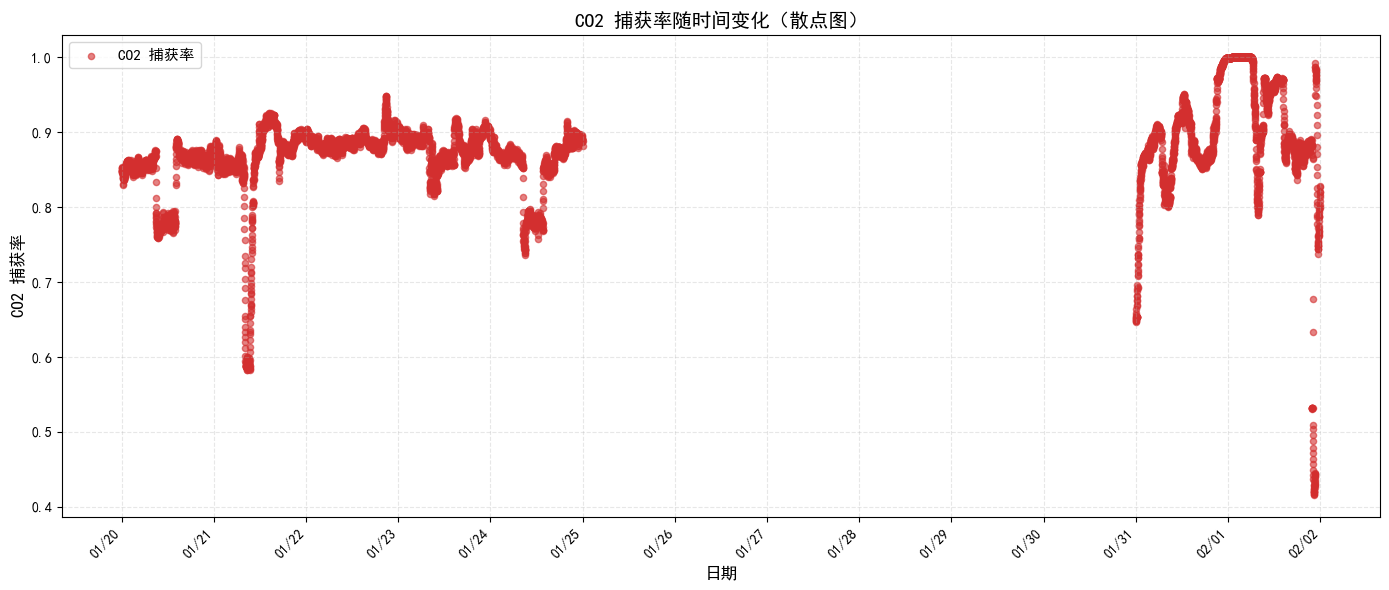

In [67]:
# 绘制 CO2 捕获率散点图
co2_data = df[target_col].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(time_index, co2_data, alpha=0.6, s=20, color='#D32F2F', label='CO2 捕获率')

# 设置 x 轴日期刻度
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# 禁用小刻度
ax.minorticks_off()

# 标签和标题
ax.set_xlabel('日期', fontsize=12, fontweight='bold')
ax.set_ylabel('CO2 捕获率', fontsize=12, fontweight='bold')
ax.set_title('CO2 捕获率随时间变化（散点图）', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# 保存和显示
plt.tight_layout()
plt.savefig('CO2_scatter.png', dpi=300, bbox_inches='tight')
print("✓ CO2 捕获率散点图已保存为 CO2_scatter.png")
plt.show()



## 第五步：数据归一化与趋势分析

In [69]:
# 数据归一化分析 - Min-Max 标准化
# 公式：X_normalized = (X - min(X)) / (max(X) - min(X))

print("=" * 60)
print("数据归一化说明")
print("=" * 60)
print("\n归一化方法：Min-Max 标准化")
print("公式：X_normalized = (X - min) / (max - min)")
print("\n关键性质：")
print("  ✓ 保留了原始数据的变化趋势（相对大小关系不变）")
print("  ✓ 只改变了数据的尺度和位置")
print("  ✓ 不影响数据的单调性和相对变化")
print("  ✓ 归一化后的数据范围为 [0, 1]")

# 提取所有特征和 CO2
all_features = ['TI-34', 'TI-33', 'TI-24', 'FI-38', 'TI-32', 'TI-242', 'TI-25', 'TI-30', 'FI-36', 'FI-30']
features_data = {}
for feat in all_features:
    features_data[feat] = df[feat].values

co2_original = df[target_col].values

# 归一化函数
def normalize_minmax(x):
    return (x - x.min()) / (x.max() - x.min())

# 归一化所有数据
features_normalized = {}
for feat in all_features:
    features_normalized[feat] = normalize_minmax(features_data[feat])

co2_normalized = normalize_minmax(co2_original)

print("\n归一化结果：")
print(f"  • 所有特征和 CO2 已归一化到 [0, 1] 范围")
print(f"  • 变化趋势：完全保留（未改变）")
print(f"  • 可以直接在同一图中比较")

# 验证：计算原始和归一化数据的相关系数（应该为 1）
print("\n验证归一化的有效性（计算原始和归一化数据的相关系数）：")
for feat in all_features[:3]:  # 只显示前 3 个特征作为示例
    corr = np.corrcoef(features_data[feat], features_normalized[feat])[0, 1]
    print(f"  • {feat}：相关系数 = {corr:.10f} ≈ 1.0 ✓")

数据归一化说明

归一化方法：Min-Max 标准化
公式：X_normalized = (X - min) / (max - min)

关键性质：
  ✓ 保留了原始数据的变化趋势（相对大小关系不变）
  ✓ 只改变了数据的尺度和位置
  ✓ 不影响数据的单调性和相对变化
  ✓ 归一化后的数据范围为 [0, 1]

归一化结果：
  • 所有特征和 CO2 已归一化到 [0, 1] 范围
  • 变化趋势：完全保留（未改变）
  • 可以直接在同一图中比较

验证归一化的有效性（计算原始和归一化数据的相关系数）：
  • TI-34：相关系数 = 1.0000000000 ≈ 1.0 ✓
  • TI-33：相关系数 = 1.0000000000 ≈ 1.0 ✓
  • TI-24：相关系数 = 1.0000000000 ≈ 1.0 ✓


## 第六步：所有特征和 CO2 的组合散点图（归一化）

✓ 组合散点图已保存为 all_features_co2_normalized.png


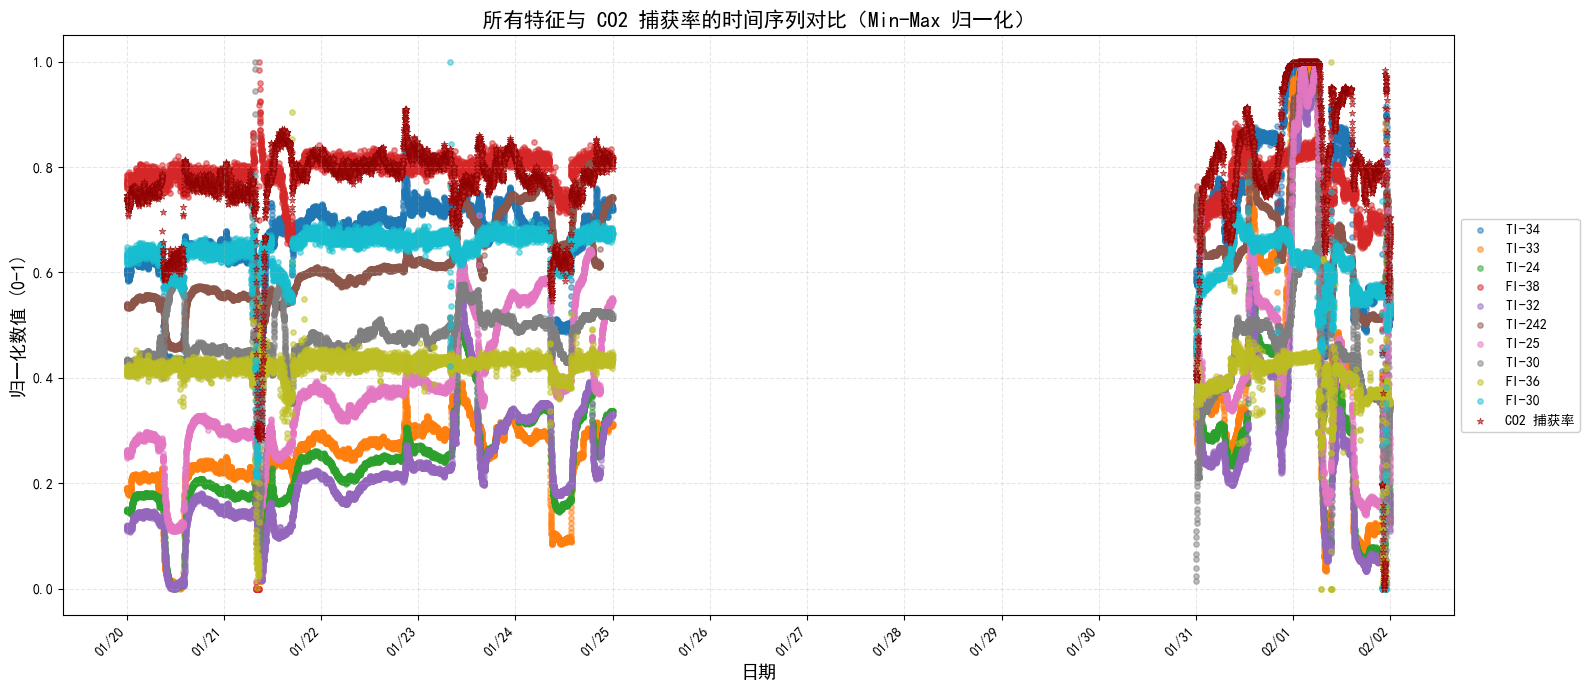


归一化后的数据统计摘要

特征         最小值        最大值        平均值        标准差       
--------------------------------------------------
TI-34      0.0000     1.0000     0.6875     0.1165    
TI-33      0.0000     1.0000     0.3030     0.1856    
TI-24      0.0000     1.0000     0.2762     0.1713    
FI-38      0.0000     1.0000     0.7785     0.0877    
TI-32      0.0000     1.0000     0.2536     0.1746    
TI-242     0.0000     1.0000     0.6331     0.1085    
TI-25      0.0000     1.0000     0.4009     0.1610    
TI-30      0.0000     1.0000     0.4713     0.0767    
FI-36      0.0000     1.0000     0.4152     0.0481    
FI-30      0.0000     1.0000     0.6330     0.0659    
CO2        0.0000     1.0000     0.7842     0.1063    


In [70]:
# 创建组合散点图 - 所有 10 个特征 + CO2（归一化）
fig, ax = plt.subplots(figsize=(16, 7))

# 定义颜色映射
colors_all = {
    'TI-34': '#1f77b4',    # 蓝色
    'TI-33': '#ff7f0e',    # 橙色
    'TI-24': '#2ca02c',    # 绿色
    'FI-38': '#d62728',    # 红色
    'TI-32': '#9467bd',    # 紫色
    'TI-242': '#8c564b',   # 棕色
    'TI-25': '#e377c2',    # 粉色
    'TI-30': '#7f7f7f',    # 灰色
    'FI-36': '#bcbd22',    # 黄绿色
    'FI-30': '#17becf',    # 青色
    'CO2': '#D32F2F'       # 深红色（突出 CO2）
}

# 绘制所有特征
for feat in all_features:
    ax.scatter(time_index, features_normalized[feat], alpha=0.5, s=15, 
              color=colors_all[feat], label=feat, marker='o')

# 绘制 CO2（用更大的点和不同的标记突出）
ax.scatter(time_index, co2_normalized, alpha=0.7, s=25, 
          color=colors_all['CO2'], label='CO2 捕获率', marker='*', edgecolors='darkred', linewidth=0.5)

# 设置 x 轴日期刻度
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# 禁用小刻度
ax.minorticks_off()

# 标签和标题
ax.set_xlabel('日期', fontsize=13, fontweight='bold')
ax.set_ylabel('归一化数值 (0-1)', fontsize=13, fontweight='bold')
ax.set_title('所有特征与 CO2 捕获率的时间序列对比（Min-Max 归一化）', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# 设置 y 轴范围
ax.set_ylim(-0.05, 1.05)

# 创建图例（分两列以节省空间）
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, ncol=1, framealpha=0.95)

plt.tight_layout()
plt.savefig('all_features_co2_normalized.png', dpi=300, bbox_inches='tight')
print("✓ 组合散点图已保存为 all_features_co2_normalized.png")
plt.show()

# 显示统计摘要
print("\n" + "=" * 60)
print("归一化后的数据统计摘要")
print("=" * 60)
print(f"\n{'特征':<10} {'最小值':<10} {'最大值':<10} {'平均值':<10} {'标准差':<10}")
print("-" * 50)
for feat in all_features:
    data = features_normalized[feat]
    print(f"{feat:<10} {data.min():<10.4f} {data.max():<10.4f} {data.mean():<10.4f} {data.std():<10.4f}")

print(f"{'CO2':<10} {co2_normalized.min():<10.4f} {co2_normalized.max():<10.4f} {co2_normalized.mean():<10.4f} {co2_normalized.std():<10.4f}")
print("=" * 60)